In [1]:
!pip install -q datasets tiktoken

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

CUDA available: True
GPU name: Tesla T4


In [5]:
import os
os.makedirs("data",exist_ok=True)
os.makedirs("outputs",exist_ok=True)
print(os.listdir())

['.config', 'outputs', 'data', 'sample_data']


In [6]:
from datasets import load_dataset
ds = load_dataset("roneneldan/TinyStories")
print(ds)

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [8]:
print(ds["train"][0]["text"])
print("---")
print(ds["train"][1]["text"])

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.
---
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were fallin

In [9]:
train_subset = ds["train"].select(range(200000))
val_subset = ds["validation"].select(range(2000))
print(len(train_subset), len(val_subset))

200000 2000


In [10]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

def encode(example):
    ids = enc.encode_ordinary(example["text"])
    ids.append(enc.eot_token)
    return {"ids": ids, "len": len(ids)}

tokenized_train = train_subset.map(encode, remove_columns=["text"], num_proc=2, desc="tokenizing train")
tokenized_val = val_subset.map(encode, remove_columns=["text"], num_proc=2, desc="tokenizing val")
print(tokenized_train)

tokenizing train (num_proc=2):   0%|          | 0/200000 [00:00<?, ? examples/s]

tokenizing val (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['ids', 'len'],
    num_rows: 200000
})


In [11]:
import numpy as np

def write_bin(dataset, filename):
    arr_len = np.sum(dataset["len"])
    arr = np.memmap(filename, dtype=np.uint16, mode="w+", shape=(arr_len,))
    idx = 0
    for example in dataset:
        ids = example["ids"]
        arr[idx: idx + len(ids)] = ids
        idx += len(ids)
    arr.flush()
    print(f"Wrote {filename}: {arr_len} tokens, {os.path.getsize(filename)/1e6:.1f} MB")

write_bin(tokenized_train, "data/train.bin")
write_bin(tokenized_val, "data/val.bin")

Wrote data/train.bin: 44970964 tokens, 89.9 MB
Wrote data/val.bin: 389121 tokens, 0.8 MB


In [12]:
check = np.memmap("data/train.bin", dtype=np.uint16, mode="r")
print(enc.decode(check[:50].tolist()))

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.



In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import shutil, os
project_dir = "/content/drive/MyDrive/slm_project"
os.makedirs(project_dir + "/data", exist_ok=True)
shutil.copy("data/train.bin", project_dir + "/data/train.bin")
shutil.copy("data/val.bin", project_dir + "/data/val.bin")
print("Saved to Google Drive:", os.listdir(project_dir + "/data"))

Saved to Google Drive: ['train.bin', 'val.bin']


In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
project_dir = "/content/drive/MyDrive/slm_project"
shutil.copy(project_dir + "/data/train.bin", "data/train.bin")
shutil.copy(project_dir + "/data/val.bin", "data/val.bin")
print(os.listdir("data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['train.bin', 'val.bin']


In [16]:
!pip install -q tiktoken
import tiktoken
enc = tiktoken.get_encoding("gpt2")
import torch
print(torch.cuda.is_available())


True


In [17]:
import math
import torch
import torch.nn as nn
from torch.nn import functional as F

class Config:
    vocab_size = 50257
    block_size = 256
    n_layer = 6
    n_head = 6
    n_embd = 384
    dropout = 0.1

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd)
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.n_head = cfg.n_head
        self.register_buffer("mask", torch.tril(torch.ones(cfg.block_size, cfg.block_size))
                              .view(1, 1, cfg.block_size, cfg.block_size))

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)

class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd), nn.GELU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd), nn.Dropout(cfg.dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class SLM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.cfg.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config()
model = SLM(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model has {n_params:,} parameters, running on {device}")

Model has 49,343,232 parameters, running on cuda


In [19]:
import numpy as np

def get_batch(split, block_size=256, batch_size=32):
    filename = "data/train.bin" if split == "train" else "data/val.bin"
    data = np.memmap(filename, dtype=np.uint16, mode="r")
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch("train")
print(xb.shape, yb.shape)

torch.Size([32, 256]) torch.Size([32, 256])


In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

for it in range(100):
    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if it % 20 == 0:
        print(f"step {it}: loss {loss.item():.4f}")

step 0: loss 10.9669
step 20: loss 6.9907
step 40: loss 5.6190
step 60: loss 5.1319
step 80: loss 4.8369


In [21]:
import time

# Fresh model for the real run
model = SLM(cfg).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

max_iters = 3000
eval_interval = 250
batch_size = 32

train_losses, val_losses = [], []
start_time = time.time()

for it in range(max_iters):
    xb, yb = get_batch("train", batch_size=batch_size)
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if it % eval_interval == 0 or it == max_iters - 1:
        model.eval()
        with torch.no_grad():
            xv, yv = get_batch("val", batch_size=batch_size)
            _, vloss = model(xv, yv)
        model.train()
        elapsed = (time.time() - start_time) / 60
        train_losses.append((it, loss.item()))
        val_losses.append((it, vloss.item()))
        print(f"step {it}/{max_iters}: train loss {loss.item():.4f}, val loss {vloss.item():.4f}, elapsed {elapsed:.1f} min")
        # save a checkpoint every eval so you never lose more than eval_interval steps of progress
        torch.save(model.state_dict(), "outputs/slm_checkpoint.pt")

print("Training complete.")

step 0/3000: train loss 11.0207, val loss 10.6154, elapsed 0.0 min
step 250/3000: train loss 3.9013, val loss 4.0056, elapsed 2.3 min
step 500/3000: train loss 3.5672, val loss 3.5429, elapsed 4.7 min
step 750/3000: train loss 3.2711, val loss 3.2912, elapsed 7.1 min
step 1000/3000: train loss 3.0078, val loss 3.2195, elapsed 9.5 min
step 1250/3000: train loss 2.9366, val loss 2.9654, elapsed 11.9 min
step 1500/3000: train loss 2.7857, val loss 2.7671, elapsed 14.2 min
step 1750/3000: train loss 2.8892, val loss 2.7286, elapsed 16.6 min
step 2000/3000: train loss 2.7002, val loss 2.5791, elapsed 19.0 min
step 2250/3000: train loss 2.6750, val loss 2.5801, elapsed 21.4 min
step 2500/3000: train loss 2.4827, val loss 2.5497, elapsed 23.8 min
step 2750/3000: train loss 2.6345, val loss 2.4985, elapsed 26.2 min
step 2999/3000: train loss 2.2424, val loss 2.5775, elapsed 28.6 min
Training complete.


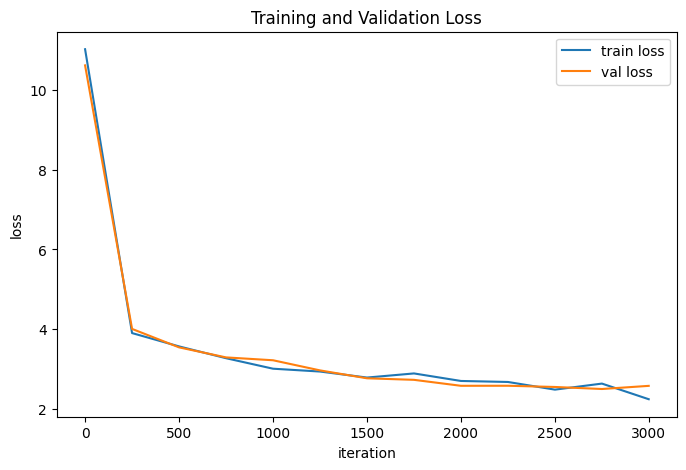

In [22]:
import matplotlib.pyplot as plt

steps_t, tl = zip(*train_losses)
steps_v, vl = zip(*val_losses)
plt.figure(figsize=(8,5))
plt.plot(steps_t, tl, label="train loss")
plt.plot(steps_v, vl, label="val loss")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig("outputs/loss_curve.png")
plt.show()

In [23]:
model.eval()
prompts = ["Once upon a time", "The little dog", "One day, a girl"]
results = []
for p in prompts:
    context = torch.tensor([enc.encode_ordinary(p)], device=device)
    out = model.generate(context, max_new_tokens=100, temperature=0.8, top_k=50)
    text = enc.decode(out[0].tolist())
    results.append(text)
    print(text)
    print("="*60)

with open("outputs/sample_generations.txt", "w") as f:
    f.write("\n\n====\n\n".join(results))

Once upon a time, there was a little girl named Lily. She loved to play in her garden. One day, she took off her shoes and accidentally knocked over a curtain. She was very happy and thanked her friends. 

As she was done, she started to feel sick and dizzy fell off the chair. She felt happy and proud of herself for being kind to him. 

But then, her friends came to visit her and they all had so much fun. They played their game of
The little dog decided to never be so rude. The dog was very happy.<|endoftext|>Once upon a time, there was a kind farmer named Sam. Sam loved to eat fruits. One day, he found a big jug. He showed it to his mom and dad. They said, "Look, a crane!" Sam said, "Wow, that is amazing!"

Sam and his mom watched the soup. Sam and his mom went into the kitchen. They brought a bowl and a bowl. They put it
One day, a girl named Lily went to the park with her mommy. They were playing tag on the swings, and Lily wanted to go home.

"Mommy, can I go home?" Lily asked.

"S

In [24]:
import shutil
shutil.copy("outputs/slm_checkpoint.pt", project_dir + "/slm_checkpoint.pt")
shutil.copy("outputs/loss_curve.png", project_dir + "/loss_curve.png")
shutil.copy("outputs/sample_generations.txt", project_dir + "/sample_generations.txt")
print("Saved:", os.listdir(project_dir))

Saved: ['data', 'slm_checkpoint.pt', 'loss_curve.png', 'sample_generations.txt']


In [25]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q tiktoken
import os, torch, tiktoken
project_dir = "/content/drive/MyDrive/slm_project"
os.makedirs("outputs", exist_ok=True)
enc = tiktoken.get_encoding("gpt2")
device = "cuda" if torch.cuda.is_available() else "cpu"

# re-run your Step 2.2 model class definitions here (Config, CausalSelfAttention, Block, SLM) — paste the same code block again

cfg = Config()
model = SLM(cfg).to(device)
model.load_state_dict(torch.load(project_dir + "/slm_checkpoint.pt", map_location=device))
model.eval()
print("Model loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully.


In [26]:
prompt = "Once upon a time"
context = torch.tensor([enc.encode_ordinary(prompt)], device=device)

settings = [
    ("temp=0.5, top_k=10", 0.5, 10),
    ("temp=0.8, top_k=50", 0.8, 50),
    ("temp=1.2, top_k=None", 1.2, None),
]

comparison = []
for label, temp, k in settings:
    out = model.generate(context, max_new_tokens=80, temperature=temp, top_k=k)
    text = enc.decode(out[0].tolist())
    comparison.append(f"--- {label} ---\n{text}")
    print(f"--- {label} ---")
    print(text)
    print()

with open("outputs/sampling_comparison.txt", "w") as f:
    f.write("\n\n".join(comparison))

--- temp=0.5, top_k=10 ---
Once upon a time there was a little girl named Lily who loved to play outside. One day, she decided to go on a walk in the park with her mommy. They went to the park and had a great time.

One day, Lily saw a little girl named Lily. She asked Lily, "What's that?"

"I have a surprise for you, Lily," replied Lily. "

--- temp=0.8, top_k=50 ---
Once upon a time, there was a little girl named Lily. She loved to play outside near her house, but sometimes she might be happy.

One day, Lily and her mom were playing outside when they heard a smoke. The thunder was big and noisy. Lily and her mom went to the kitchen and saw a little girl who was hungry. They decided to go inside the sink. When they were done,

--- temp=1.2, top_k=None ---
Once upon a time there was a little puppy. TheWhen everyone in two were chugigators all the Lia, there was lots of105 in the jungle shiningerved and zero. Then, something bad happened! The dog started upstairs in mosquito. Soon it wa

In [27]:
import math
model.eval()
with torch.no_grad():
    xv, yv = get_batch("val", batch_size=32)  # re-run Step 2.4's get_batch cell first if not already in memory
    _, final_val_loss = model(xv, yv)
perplexity = math.exp(final_val_loss.item())
print(f"Final validation loss: {final_val_loss.item():.4f}")
print(f"Perplexity: {perplexity:.2f}")

Final validation loss: 2.4170
Perplexity: 11.21
